In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import LabelEncoder

In [2]:
# 데이터 불러오기
df = pd.read_csv('../data/무_월차낼게요.csv', encoding='cp949')
df_grow = pd.read_csv('../data/factor_external_weekly_ver_0721.csv', encoding='utf-8')

In [3]:
df['총거래량(kg)'] = np.log1p(df['총거래량(kg)'])

In [4]:
df.head()


,year,week,week_start,품종코드,등급코드,직팜산지코드,총거래량(kg),일평균기온,최고기온,최저기온,...,최저기온_t-2,평균상대습도_t-2,강수량(mm)_t-2,1시간최고강수량(mm)_t-2,일평균기온_t-3,최고기온_t-3,최저기온_t-3,평균상대습도_t-3,강수량(mm)_t-3,1시간최고강수량(mm)_t-3
0,2018,13,2018-03-26,100,11,1079,7.365813,16.800000,24.1,12.3,...,-6.550,52.208333,1.050,0.0,-0.685417,5.000,-5.525,72.120833,5.300,0.0
1,2018,13,2018-03-26,100,11,1137,9.261129,13.600000,17.6,9.4,...,0.975,62.008333,1.375,0.0,7.069048,12.675,3.300,71.919048,9.900,0.0
2,2018,13,2018-03-26,100,11,1170,6.398595,15.600000,19.3,12.0,...,0.550,57.207500,3.500,0.0,6.950000,11.250,3.175,69.987500,7.400,0.0
3,2018,13,2018-03-26,100,12,1000,8.692994,11.000000,18.1,5.3,...,-9.575,54.875000,1.750,0.0,-3.384821,3.275,-7.000,52.450893,1.050,0.0
4,2018,13,2018-03-26,100,12,1079,7.090910,14.333333,23.4,7.0,...,-5.875,55.605000,0.200,0.0,1.635000,7.225,-3.075,69.767500,8.275,0.0


In [5]:
# year, week 파생
def format_week_int(weekno):
    year = weekno // 100
    week = weekno % 100
    return year, week

df_grow[['year', 'week']] = df_grow['weekno'].apply(lambda x: pd.Series(format_week_int(x)))
df_grow.drop(columns='weekno', inplace=True)

# 병합 전 품목코드 추가
df['item_code'] = 1101

# 외생변수 병합
df = pd.merge(
    df,
    df_grow[['year', 'week', 'item_code', 'holiday_flag', 'holiday_score', 'grow_score']],
    on=['year', 'week', 'item_code'],
    how='left'
)

# 병합 후 외생변수 컬럼 재정의
for col in ['holiday_flag', 'holiday_score', 'grow_score']:
    if f"{col}_y" in df.columns:
        df[col] = df[f"{col}_y"]
        df.drop(columns=[f"{col}_x", f"{col}_y"], inplace=True)
df.drop(columns='item_code', inplace=True)

In [6]:
df.columns

Index(['year', 'week', 'week_start', '품종코드', '등급코드', '직팜산지코드', '총거래량(kg)',
       '일평균기온', '최고기온', '최저기온', '평균상대습도', '강수량(mm)', '1시간최고강수량(mm)', '평균단가(원)',
       '일평균기온_t-1', '최고기온_t-1', '최저기온_t-1', '평균상대습도_t-1', '강수량(mm)_t-1',
       '1시간최고강수량(mm)_t-1', '일평균기온_t-2', '최고기온_t-2', '최저기온_t-2', '평균상대습도_t-2',
       '강수량(mm)_t-2', '1시간최고강수량(mm)_t-2', '일평균기온_t-3', '최고기온_t-3', '최저기온_t-3',
       '평균상대습도_t-3', '강수량(mm)_t-3', '1시간최고강수량(mm)_t-3', 'holiday_flag',
       'holiday_score', 'grow_score'],
      dtype='object')

In [7]:
# 불필요 컬럼 제거
# df = df.drop(columns=['등급코드', '일평균기온', '최고기온', '최저기온', '평균상대습도', '강수량(mm)', '1시간최고강수량(mm)'], errors='ignore')

In [8]:
# 0. 최소 연도 확인 (예: 2018)
min_year = df['year'].min()

# 1. 병합 대상 테이블 생성 (중복 제거 중요!)
price_lag = (
    df[['year', 'week', '직팜산지코드', '품종코드', '평균단가(원)']]
    .drop_duplicates(subset=['year', 'week', '직팜산지코드', '품종코드'])
    .copy()
)
price_lag['year'] += 1
price_lag = price_lag.rename(columns={'평균단가(원)': 'price_lag_1y'})

# 2. 병합 수행 (1:1 보장)
df = pd.merge(
    df,
    price_lag,
    on=['year', 'week', '직팜산지코드', '품종코드'],
    how='left'
)

# 3. 월 기준 평균단가로 보완
df['month'] = pd.to_datetime(df['week_start']).dt.month

monthly_avg = (
    df[['year', 'month', '직팜산지코드', '품종코드', '평균단가(원)']]
    .groupby(['year', 'month', '직팜산지코드', '품종코드'], as_index=False)
    .mean()
)

monthly_avg['year'] += 1
monthly_avg = monthly_avg.rename(columns={'평균단가(원)': 'price_lag_month_fill'})

df = pd.merge(
    df,
    monthly_avg,
    on=['year', 'month', '직팜산지코드', '품종코드'],
    how='left'
)

# 📌 월평균으로 보완 (단, 최소 연도는 제외)
df['price_lag_1y'] = df.apply(
    lambda row: row['price_lag_month_fill']
    if pd.isna(row['price_lag_1y']) and row['year'] > min_year
    else row['price_lag_1y'],
    axis=1
)

# 4. 연 평균으로 fallback
yearly_avg = (
    df[['year', '직팜산지코드', '품종코드', '평균단가(원)']]
    .groupby(['year', '직팜산지코드', '품종코드'], as_index=False)
    .mean()
)
yearly_avg['year'] += 1
yearly_avg = yearly_avg.rename(columns={'평균단가(원)': 'price_lag_fallback'})

df = pd.merge(
    df,
    yearly_avg,
    on=['year', '직팜산지코드', '품종코드'],
    how='left'
)

df['price_lag_1y'] = df.apply(
    lambda row: row['price_lag_fallback']
    if pd.isna(row['price_lag_1y']) and row['year'] > min_year
    else row['price_lag_1y'],
    axis=1
)
df.dropna(subset=['price_lag_1y'], inplace=True)

In [9]:
print("병합 후 행 수:", len(df))
print("NaN 비율:", df['price_lag_1y'].isna().mean())

병합 후 행 수: 74775
NaN 비율: 0.0


In [10]:
# df.drop(columns=['month', 'price_lag_month_fill', 'price_lag_fallback'], inplace=True, errors='ignore')

df.sample(5)

,year,week,week_start,품종코드,등급코드,직팜산지코드,총거래량(kg),일평균기온,최고기온,최저기온,...,평균상대습도_t-3,강수량(mm)_t-3,1시간최고강수량(mm)_t-3,holiday_flag,holiday_score,grow_score,price_lag_1y,month,price_lag_month_fill,price_lag_fallback
86699,2025,22,2025-05-26,100,11,1137,8.767329,18.800000,22.5,15.1,...,58.310000,0.750,0.00,2,0.0,2,940.0,5,647.428571,649.072072
65256,2023,28,2023-07-10,100,13,1069,7.427144,24.900000,26.3,23.6,...,83.889583,48.975,14.80,2,0.0,27,950.0,7,781.500000,577.846154
65152,2023,28,2023-07-10,2,11,1116,6.908755,24.500000,27.6,22.5,...,71.640000,4.725,1.25,2,0.0,27,1159.0,7,774.666667,665.681159
75666,2024,26,2024-06-24,1,13,1094,8.131825,22.266667,29.2,17.1,...,71.375000,0.850,0.00,2,0.0,21,775.0,6,452.285714,578.690476
41098,2021,19,2021-05-10,99,12,1138,10.884461,17.147059,30.4,11.1,...,52.843750,0.000,0.00,2,0.0,0,386.0,5,303.545455,497.491071


In [11]:
print("남은 컬럼:\n", df.columns.tolist())


남은 컬럼:
 ['year', 'week', 'week_start', '품종코드', '등급코드', '직팜산지코드', '총거래량(kg)', '일평균기온', '최고기온', '최저기온', '평균상대습도', '강수량(mm)', '1시간최고강수량(mm)', '평균단가(원)', '일평균기온_t-1', '최고기온_t-1', '최저기온_t-1', '평균상대습도_t-1', '강수량(mm)_t-1', '1시간최고강수량(mm)_t-1', '일평균기온_t-2', '최고기온_t-2', '최저기온_t-2', '평균상대습도_t-2', '강수량(mm)_t-2', '1시간최고강수량(mm)_t-2', '일평균기온_t-3', '최고기온_t-3', '최저기온_t-3', '평균상대습도_t-3', '강수량(mm)_t-3', '1시간최고강수량(mm)_t-3', 'holiday_flag', 'holiday_score', 'grow_score', 'price_lag_1y', 'month', 'price_lag_month_fill', 'price_lag_fallback']


In [12]:
# y, X 분리
y = df['평균단가(원)']
X = df.drop(columns=['평균단가(원)'])

In [17]:
def generate_moving_averages_fixed(df, target_col='평균단가(원)', group_cols=['직팜산지코드', '품종코드'], windows=[4, 13, 26]):
    """
    데이터 누수를 방지하고 이동평균 피처를 생성하는 수정된 함수
    """
    df = df.sort_values(group_cols + ['year', 'week']).copy()

    # 1. 그룹별로 target 값을 shift하여 임시 컬럼 생성 (데이터 누수 방지)
    df['shifted_target'] = df.groupby(group_cols)[target_col].shift(1)

    # 2. shift된 컬럼을 기준으로 이동 통계 피처 계산
    for w in windows:
        df[f'SMA_{w}'] = df.groupby(group_cols)['shifted_target'].transform(
            lambda x: x.rolling(window=w, min_periods=1).mean()
        )
        df[f'EMA_{w}'] = df.groupby(group_cols)['shifted_target'].transform(
            lambda x: x.ewm(span=w, adjust=False).mean()
        )

    # 3. 위에서 계산된 EMA 피처를 기반으로 파생 변수 생성
    df['EMA4_SMA4_diff'] = df['EMA_4'] - df['SMA_4']
    df['EMA13_SMA13_diff'] = df['EMA_13'] - df['SMA_13']
    df['EMA26_SMA26_diff'] = df['EMA_26'] - df['SMA_26']

    df['EMA_4_rate'] = df.groupby(group_cols)['EMA_4'].transform(lambda x: x.pct_change().fillna(0))
    df['EMA_13_rate'] = df.groupby(group_cols)['EMA_13'].transform(lambda x: x.pct_change().fillna(0))
    df['EMA_26_rate'] = df.groupby(group_cols)['EMA_26'].transform(lambda x: x.pct_change().fillna(0))

    # 4. 임시로 사용한 컬럼 제거
    df = df.drop(columns=['shifted_target'])

    return df

# 수정된 함수를 호출합니다.
df_fixed = generate_moving_averages_fixed(df)

moving_avg_cols = [
    'SMA_4', 'SMA_13', 'SMA_26',
    'EMA_4', 'EMA_13', 'EMA_26',
    'EMA4_SMA4_diff', 'EMA13_SMA13_diff', 'EMA26_SMA26_diff',
    'EMA_4_rate', 'EMA_13_rate', 'EMA_26_rate', 'holiday_flag',
    'holiday_score', 'grow_score', 'price_lag_1y'
]

# df_final 이라는 새 변수에 결측값이 제거된 최종 데이터를 저장
df = df_fixed.dropna(subset=moving_avg_cols).copy()


C:\Users\Admin\AppData\Local\Temp\ipykernel_19932\2266228102.py:24: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['EMA_4_rate'] = df.groupby(group_cols)['EMA_4'].transform(lambda x: x.pct_change().fillna(0))
C:\Users\Admin\AppData\Local\Temp\ipykernel_19932\2266228102.py:25: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['EMA_13_rate'] = df.groupby(group_cols)['EMA_13'].transform(lambda x: x.pct_change().fillna(0))
C:\Users\Admin\AppData\Local\Temp\ipykernel_19932\2266228102.py:26: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a futur

In [18]:
# 모델 학습용 재분리 및 주기형 변수 처리
y = df['평균단가(원)']
X = df.drop(columns=['평균단가(원)'])

# ✅ 여기서 제거하는 게 베스트!
X = X.drop(columns=[
    '등급코드', '일평균기온', '최고기온', '최저기온',
    '평균상대습도', '강수량(mm)', '1시간최고강수량(mm)',
    'month', 'price_lag_month_fill', 'price_lag_fallback'
], errors='ignore')

X['week_start'] = pd.to_datetime(X['week_start'])
X['year'] = X['week_start'].dt.year
X['week'] = X['week_start'].dt.isocalendar().week.astype(int)

X['week_sin'] = np.sin(2 * np.pi * X['week'] / 52)
X['week_cos'] = np.cos(2 * np.pi * X['week'] / 52)
X = X.drop(columns=['week'])


In [19]:
X_train = X[X['year'] < 2025].drop(columns=['week_start'])
y_train = y[X['year'] < 2025]
X_test = X[X['year'] == 2025].drop(columns=['week_start'])
y_test = y[X['year'] == 2025]


In [20]:
from sklearn.preprocessing import RobustScaler

exclude_cols = ['year', '품종코드', '직팜산지코드']  # 범주형 및 예외
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
scale_cols = [col for col in numerical_cols if col not in exclude_cols]

scaler = RobustScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

In [21]:
cat_cols = ['직팜산지코드', '품종코드']

for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

In [22]:
# df.sample(5)
X_train.isna().sum(), X_test.isna().sum()
# train_df.info()
# test_df.info()

(year                0
 품종코드                0
 직팜산지코드              0
 총거래량(kg)            0
 일평균기온_t-1           0
 최고기온_t-1            0
 최저기온_t-1            0
 평균상대습도_t-1          0
 강수량(mm)_t-1         0
 1시간최고강수량(mm)_t-1    0
 일평균기온_t-2           0
 최고기온_t-2            0
 최저기온_t-2            0
 평균상대습도_t-2          0
 강수량(mm)_t-2         0
 1시간최고강수량(mm)_t-2    0
 일평균기온_t-3           0
 최고기온_t-3            0
 최저기온_t-3            0
 평균상대습도_t-3          0
 강수량(mm)_t-3         0
 1시간최고강수량(mm)_t-3    0
 holiday_flag        0
 holiday_score       0
 grow_score          0
 price_lag_1y        0
 SMA_4               0
 EMA_4               0
 SMA_13              0
 EMA_13              0
 SMA_26              0
 EMA_26              0
 EMA4_SMA4_diff      0
 EMA13_SMA13_diff    0
 EMA26_SMA26_diff    0
 EMA_4_rate          0
 EMA_13_rate         0
 EMA_26_rate         0
 week_sin            0
 week_cos            0
 dtype: int64,
 year                0
 품종코드                0
 직팜산지코드            

In [23]:
# 1. 필요한 라이브러리 불러오기
from catboost import CatBoostRegressor

# 2. 범주형 피처 지정 (인코딩 전의 원본 컬럼 이름 사용)
# 기존 코드에서 X_train, y_train, X_test, y_test는 이미 만들어져 있다고 가정합니다.
# RobustScaler는 그대로 사용해도 좋습니다.
# 단, CatBoost를 위해 LabelEncoder는 적용하지 않은 X_train 데이터가 필요합니다.
# 만약 이미 인코딩했다면, 인코딩 전 단계에서 데이터를 새로 분리해주세요.

cat_features = ['직팜산지코드', '품종코드'] # 범주형 변수 목록

# 3. CatBoost 모델 생성 및 학습
# random_state: 결과 재현을 위한 시드
# iterations, learning_rate, depth: 주요 하이퍼파라미터 (튜닝 가능)
# cat_features: 범주형 피처를 알려주어 모델이 자동으로 처리하도록 함
cat_model = CatBoostRegressor(
    random_state=42,
    iterations=1000,
    learning_rate=0.05,
    depth=10,
    cat_features=cat_features,
    verbose=100  # 100번 학습마다 로그 출력
)

# 모델 학습
cat_model.fit(X_train, y_train)

# 4. 예측 및 성능 평가
pred_cat = cat_model.predict(X_test)

# 성능 평가 (기존 코드와 동일)
rmse_cat = np.sqrt(mean_squared_error(y_test, pred_cat))
mae_cat = mean_absolute_error(y_test, pred_cat)
mape_cat = mean_absolute_percentage_error(y_test, pred_cat) * 100
r2_cat = r2_score(y_test, pred_cat)

print("\\n🏁 CatBoost 모델 성능:")
print(f"📉 RMSE: {rmse_cat:.2f}")
print(f"📊 MAE : {mae_cat:.2f}")
print(f"📊 MAPE: {mape_cat:.2f}%")
print(f"📈 R²   : {r2_cat:.4f}")

0:	learn: 312.9369741	total: 316ms	remaining: 5m 15s
100:	learn: 209.7530318	total: 17.7s	remaining: 2m 37s
200:	learn: 193.0273363	total: 34.8s	remaining: 2m 18s
300:	learn: 179.3924444	total: 52s	remaining: 2m
400:	learn: 167.7330920	total: 1m 11s	remaining: 1m 46s
500:	learn: 158.5669463	total: 1m 30s	remaining: 1m 30s
600:	learn: 150.8522435	total: 1m 49s	remaining: 1m 12s
700:	learn: 143.6246543	total: 2m 8s	remaining: 54.8s
800:	learn: 137.0291077	total: 2m 28s	remaining: 36.9s
900:	learn: 131.2389344	total: 2m 48s	remaining: 18.5s
999:	learn: 125.7968960	total: 3m 8s	remaining: 0us
\n🏁 CatBoost 모델 성능:
📉 RMSE: 391.78
📊 MAE : 315.04
📊 MAPE: 46.32%
📈 R²   : 0.0125


In [24]:
# ✅ 성능 지표 계산
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
mape = mean_absolute_percentage_error(y_test, pred) * 100  # %

r2 = r2_score(y_test, pred)

# ✅ 출력
print("\n🏁 모델 성능:")
print(f"📉 RMSE: {rmse:.2f}")
print(f"📊 MAE : {mae:.2f}")
print(f"📊 MAPE: {mape:.2f}%")
print(f"📈 R²   : {r2:.4f}")

NameError: name 'pred' is not defined

In [25]:
# 중요도 추출
importances = model.feature_importances_
feature_names = X_train.columns

# Series로 보기 좋게
import pandas as pd
feat_importance = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# 출력
print("\n🔍 변수 중요도 Top 10")
print(feat_importance.head(10))

NameError: name 'model' is not defined

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ✅ 1. 변수 중요도 추출 (Gain 기준)

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_  # ✅ LightGBM이든 RF든 OK
}).sort_values("importance", ascending=False).reset_index(drop=True)

# 시각화
top_n = 20
plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"][:top_n][::-1], importance_df["importance"][:top_n][::-1])
plt.xlabel("중요도")
plt.title(f"Top {top_n} 변수 중요도")
plt.tight_layout()
plt.grid(True, axis="x", linestyle="--", alpha=0.5)
plt.show()


NameError: name 'model' is not defined

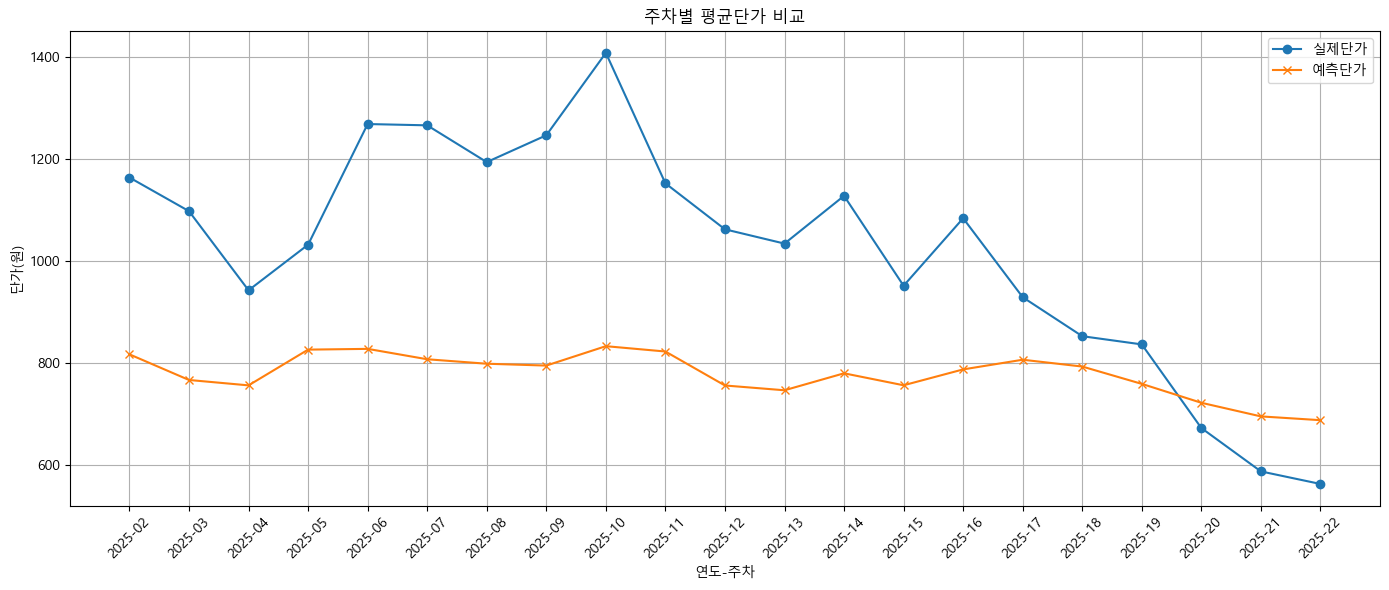

In [28]:
# 1. 예측 결과와 실제값 결합
df_result = pd.DataFrame({
    'index': y_test.index,
    '실제단가': y_test.values,
    '예측단가': pred_cat
})

# 2. 원본 df에서 'year', 'week' 컬럼만 추출해서 join
df_meta = df[['year', 'week']].reset_index()  # 원본 df에서 날짜 정보 추출
df_result = df_result.merge(df_meta, how='left', on='index')  # index 기준으로 날짜 정보 병합

# 3. 주차별 평균 계산
df_weekly = df_result.groupby(['year', 'week'])[['실제단가', '예측단가']].mean().reset_index()
# 1. year와 week를 문자열로 붙인 새 컬럼 생성 (예: '2025-01')
df_weekly['연도주차'] = df_weekly['year'].astype(str) + '-' + df_weekly['week'].astype(str).str.zfill(2)


# 4. 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(df_weekly['연도주차'], df_weekly['실제단가'], label='실제단가', marker='o')
plt.plot(df_weekly['연도주차'], df_weekly['예측단가'], label='예측단가', marker='x')
plt.title('주차별 평균단가 비교')
plt.xlabel('연도-주차')
plt.ylabel('단가(원)')
plt.xticks(rotation=45)  # x축 라벨이 겹치지 않도록 회전
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()